In [2]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np


import jax.numpy as jnp
import jax
from functools import partial

@partial(jax.jit, static_argnames=['P','Q'])
def getKsTerms(Xs1,Xs2,P,Q,M=jnp.inf,F=jnp.inf):
    #P=jnp.shape(Xs1)[0]
    #Q=jnp.shape(Xs1)[1]
    
    Phr=(P-1)/(M-1)
    Qhr=(Q-1)/(F-1)
    
    if P<Q:
        Kv=1/Q*jnp.matmul(Xs1,Xs2.T)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/P))
        #nTrKs_min2=jnp.mean(jnp.square(1/Q*jnp.matmul(Xs1,Xs2.T)))
    else:
        Kv=1/P*jnp.matmul(Xs1.T,Xs2)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/Q))
        #nTrKs_min2=jnp.mean(jnp.square(1/P*jnp.matmul(Xs1.T,Xs2)))
            
    Term2=-(1-Phr)/P * jnp.mean(jnp.square(jnp.mean(Xs1*Xs2,axis=1)))
    Term3=-(1-Qhr)/Q * jnp.mean(jnp.square(jnp.mean(Xs1*Xs2,axis=0)))
    Term4=((1-Phr)*(1-Qhr))/(P*Q) * jnp.mean(jnp.power(Xs1*Xs2,2))
        
    v =  Term2 + Term3 + Term4
    
    nsTrKs = jnp.square(jnp.mean(Xs1*Xs2))
    
    # if M and F are infinite, or even if M and F are finite:
    numer =  (nsTrKs +v)
    denom =  (nTrKs_min2 +v)

    naive=[nsTrKs, nTrKs_min2]
    row_exp=[nsTrKs+Term2,  nTrKs_min2+Term2]
    col_exp=[nsTrKs+Term3,  nTrKs_min2+Term3]
    double_exp=[numer, denom]
        
    return naive, row_exp, col_exp, double_exp


@partial(jax.jit, static_argnames=['P','Q'])
def getKsTerms2(Xs1,Xs2,P,Q,M=jnp.inf,F=jnp.inf):
    #P=jnp.shape(Xs1)[0]
    #Q=jnp.shape(Xs1)[1]
    #Xs1=Xs1_o-jnp.sum(Xs1_o,axis=0)/P
    #Xs2=Xs2_o-jnp.sum(Xs2_o,axis=0)/P

    Phr=(P-1)/(M-1)
    Qhr=(Q-1)/(F-1)
    
    if P<Q:
        Kv=1/Q*jnp.matmul(Xs1,Xs2.T)
        nTrKs_min2=jnp.sum(jnp.diag(jnp.linalg.matrix_power(Kv,2)/P))/P
        #nTrKs_min2=jnp.mean(jnp.square(1/Q*jnp.matmul(Xs1,Xs2.T)))
    else:
        Kv=1/P*jnp.matmul(Xs1.T,Xs2)
        nTrKs_min2=jnp.sum(jnp.diag(jnp.linalg.matrix_power(Kv,2)/Q))/Q
        #nTrKs_min2=jnp.mean(jnp.square(1/P*jnp.matmul(Xs1.T,Xs2)))
            
    Term2=-(1-Phr)/P * jnp.sum(jnp.square(jnp.sum(Xs1*Xs2,axis=1)/Q ))/P
    Term3=-(1-Qhr)/Q * jnp.sum(jnp.square(jnp.sum(Xs1*Xs2,axis=0)/P ))/Q
    Term4=((1-Phr)*(1-Qhr))/(P*Q) * jnp.sum(jnp.power(Xs1*Xs2,2))/(P*Q)
        
    v =  Term2 + Term3 + Term4
    
    nsTrKs = jnp.square(jnp.sum(Xs1*Xs2)/(P*Q))
    
    # if M and F are infinite, or even if M and F are finite:
    numer =  (nsTrKs +v)
    denom =  (nTrKs_min2 +v)

    naive=[nsTrKs, nTrKs_min2]
    row_exp=[nsTrKs+Term2,  nTrKs_min2+Term2]
    col_exp=[nsTrKs+Term3,  nTrKs_min2+Term3]
    double_exp=[numer, denom]
        
    return naive, row_exp, col_exp, double_exp



from functools import partial

def gett_all(ijlm, A):
    i, j, l, m = list(ijlm)
    pexp = i+'a,'+j+'a,'+l+'b,'+m+'b->'
    qexp = i+'a,'+j+'a,'+l+'a,'+m+'a->'
    pval = jnp.einsum(pexp, A, A, A, A)
    pqval = pval - jnp.einsum(qexp, A, A, A, A)
    return pval,pqval

@partial(jax.jit, static_argnames=['P','Q'])
def getest_all(A,P,Q):
    nf = jnp.sqrt(P)*jnp.sqrt(Q)
    # Wrap *all* the following in a single shared_intermediates context
    #with shared_intermediates():
    t1,t1d = gett_all('ijji', A/nf)
    t2,t2d = gett_all('iiii', A/nf)
    t3,t3d = gett_all('ijjj', A/nf)
    #t4,t4d = gett_all('iiij', A/nf)#<
    t5,t5d = gett_all('ijjl', A/nf)
    t6,t6d = gett_all('iijj', A/nf)
    t7,t7d = gett_all('iijl', A/nf)
    #t8,t8d = gett_all('ijll', A/nf)#<
    t9,t9d = gett_all('ijlm', A/nf)

    f1 = P / (P - 2)
    f2 = 2 / (P - 2)
    f3 = (1/(P-1))*(1/(P-2))

    denom_n = t1 - 2/P * t5 + (1/P)**2 * t9
    denom_s = P/(P-3) * (
        t1
        - f1 * t2
        + f2 * (2*t3 - t5)
        + f3 * (t6 - 2*t7 + t9)
    )
    denom_d = (P/(P-3))*(Q/(Q-1)) * (
        t1d
        - f1 * t2d
        + f2 * (2*t3d - t5d)
        + f3 * (t6d - 2*t7d + t9d)
    )

    numer_n = t6 - 2/P * t7 + (1/P)**2 * t9
    numer_s = P/(P-3) * (
        t6 
        - 2/(P-1) * t7 
        + 1/(P-2) * (4*t3 - P*t2) 
        + f3 * (t9 - 4*t5 + 2*t1 - t6) 
    )
    numer_d = (P/(P-3))*(Q/(Q-1))*(
        t6d 
        - 2/(P-1) * t7d 
        + 1/(P-2) * (4*t3d - P*t2d) 
        + f3 * (t9d - 4*t5d + 2*t1d - t6d) 
    )

    naive=[numer_n, denom_n]
    row_exp=[numer_s,  denom_s]
    double_exp=[numer_d, denom_d]
    
    return naive, row_exp, [np.nan,np.nan], double_exp
    
def sample_torus(n, r, d, seed=None):
    if seed is not None:
        np.random.seed(seed)

    # Step 1: Sample r angles uniformly from [0, 2π) for each of the n points
    # Shape: (n, r)
    theta = 2.0 * np.pi * np.random.rand(n, r)
    
    # Step 2: Map each angle to (cos, sin) coordinates.
    # We'll stack them in the order: [cos(theta_1), sin(theta_1), ..., cos(theta_r), sin(theta_r)].
    # Resulting shape: (n, 2r)
    Y = np.empty((n, 2*r))
    for i in range(r):
        Y[:, 2*i]   = np.cos(theta[:, i])
        Y[:, 2*i+1] = np.sin(theta[:, i])
    
    # If d == 2r, we are done (the torus is in its natural 2r-dim space)
    if d == 2*r:
        print('wewe')
        return Y
    
    # Step 3: Embed in R^d by multiplying by a random (2r) x d matrix
    #   X = Y * W  (broadcasting each row of Y)
    W = np.random.randn(2*r, d)  # random Gaussian
    X = Y @ W  # shape (n, d)
    return jnp.array(X)



In [3]:

@jax.jit
def find_neighbors_naive_jax_jitted(X, R, chosen_indices):
    """
    Computes, for each index in `chosen_indices`, which rows in X lie
    within radius R of X[index]. Returns a boolean mask of shape (S, P),
    the array of neighbor counts, and the max neighbor count.
    
    X: jnp.array of shape (P, Q)
    R: float (radius)
    chosen_indices: jnp.array of shape (S,) - the row indices chosen without replacement
    
    Returns:
       neighbors_mask: boolean array of shape (S, P) 
                       neighbors_mask[i, j] = True if sample j is within R of chosen_indices[i]
       neighbors_count: int32 array of shape (S,) 
                       neighbors_count[i] = number of True entries in neighbors_mask[i]
       max_neighbors: a scalar int32, the maximum neighbor count across i
    """
    R2 = R * R

    def compute_neighbors_mask(idx):
        # For a single index, compute distance^2 to all points
        dist_sq = jnp.mean((X - X[idx])**2, axis=1)   # shape (P,)
        # Boolean mask: whether each point is within radius R
        within_mask = dist_sq <= R2
        # Count how many True in this mask
        count = jnp.sum(within_mask)
        return within_mask, count

    # Vectorize (vmap) over each chosen index
    neighbors_mask, neighbors_count = jax.vmap(compute_neighbors_mask)(chosen_indices)
    # neighbors_mask: shape (S, P)
    # neighbors_count: shape (S,)

    max_neighbors = jnp.max(neighbors_count)

    return neighbors_mask, neighbors_count, max_neighbors


def find_neighbors_naive_jax(X, R, S, key):
    """
    Wrapper function that:
    1) Samples S distinct indices from X
    2) Calls the JIT-compiled routine to compute the neighbor masks
    3) Converts the neighbor masks to a Python list of jnp-arrays (neighbors_list)
    4) Prints 'no data' if max_neighbors == 0
    5) Returns chosen_indices, neighbors_list, max_neighbors

    X: jax.numpy array of shape (P, Q)
    R: float, radius
    S: int, number of points to subsample
    key: jax.random.PRNGKey
    """

    P, _ = X.shape

    # 1) Sample S distinct indices
    chosen_indices = jax.random.choice(key, P, shape=(S,), replace=False)

    # 2) Call the JIT-compiled function
    neighbors_mask, neighbors_count, max_neighbors = find_neighbors_naive_jax_jitted(
        X, R, chosen_indices
    )

    # 3) Convert the boolean masks to a Python list of neighbor index arrays
    #    Because each row i in neighbors_mask is shape (P,)
    #    we find the where() indices for all True values.
    #    This is done in Python space, so it won't be JIT-compiled (which is fine).
    neighbors_list = []
    for i in range(S):
        # Grab all j where neighbors_mask[i, j] == True
        these_neighbors = jnp.where(neighbors_mask[i])[0]
        # If you want to skip single-point or zero neighbors, you can do:
        if neighbors_count[i] < 2:
            continue
        neighbors_list.append(these_neighbors)

    return chosen_indices, neighbors_list, max_neighbors


import jax
import jax.numpy as jnp

def twoNN_intrinsic_dimension(X, subsample=None, key=None):
    """
    Estimate the intrinsic dimension of a dataset using the Two Nearest Neighbors (TwoNN) algorithm.
    
    Args:
        X (jnp.ndarray): Input data of shape (N, D) where N is the number of samples
                         and D is the number of features.
        subsample (int, optional): If provided and N is large, randomly choose 'subsample' points
                                   from X for the estimation.
        key (jax.random.PRNGKey, optional): PRNG key for random sampling (required if subsample is not None).
    
    Returns:
        float: Estimated intrinsic dimension using the TwoNN method.
    """
    N, D = X.shape

    # Possibly subsample the dataset if requested
    if subsample is not None and subsample < N:
        if key is None:
            raise ValueError("A jax.random.PRNGKey must be provided when subsample is used.")
        indices = jax.random.choice(key, N, shape=(subsample,), replace=False)
        X = X[indices]
        N = subsample

    # Compute the pairwise distance matrix (squared distances)
    # shape: (N, N)
    # We add a small epsilon to avoid exact zeros due to floating precision (if any).
    dist_sq = jnp.sum((X[:, None, :] - X[None, :, :])**2, axis=-1)

    # Get actual distances
    distances = jnp.sqrt(dist_sq + 1e-12)

    # Sort the distances for each point
    # sorted_distances[i, :] will have distances in ascending order for point i
    sorted_distances = jnp.sort(distances, axis=1)

    # The 0th item in each row is the distance to itself (0), so:
    # nearest neighbor distance = sorted_distances[:, 1]
    # second nearest neighbor distance = sorted_distances[:, 2]
    r1 = sorted_distances[:, 1]
    r2 = sorted_distances[:, 2]

    # Compute ratio mu = r2 / r1
    # (Add small epsilon to r1 to avoid division by zero if there are duplicates)
    mu = r2 / (r1 + 1e-12)

    # Intrinsic dimension estimate
    # d = 1 / mean(log(mu))
    log_mu = jnp.log(mu)
    d_est = 1.0 / jnp.mean(log_mu)

    return d_est





In [42]:

#@jax.jit
def find_knn_jax_jitted(X, k, chosen_indices):
    """
    JIT-compiled function that:
    - For each index in `chosen_indices`, computes the distances to every row in X.
    - Finds the k nearest neighbors (smallest distances).
    - Returns an (S, k) array of neighbor indices, where S = len(chosen_indices).

    X: jnp.array of shape (P, Q)
    k: integer, number of nearest neighbors to return
    chosen_indices: jnp.array of shape (S,) with the row indices chosen without replacement

    Returns:
       neighbors_indices: jnp.array of shape (S, k)
                         neighbors_indices[i, :] are the k nearest neighbors of chosen_indices[i]
    """

    def knn_for_index(idx):
        # dist_sq[j] = || X[j] - X[idx] ||^2
        dist_sq = jnp.sum((X - X[idx])**2, axis=1)
        # Get indices that sort dist_sq in ascending order
        sorted_indices = jnp.argsort(dist_sq)
        # Take the first k
        top_k_indices = sorted_indices[:k]
        return top_k_indices

    # Vectorize over chosen_indices
    neighbors_indices = jax.vmap(knn_for_index)(chosen_indices)  # shape (S, k)
    return neighbors_indices


def find_neighbors_kNN_jax(X, k, S, key):
    """
    Wrapper function that:
    1) Samples S distinct indices from X
    2) Calls the JIT-compiled routine to compute the k-NN indices
    3) Converts the k-NN result to a Python list of jnp-arrays (neighbors_list)
    4) Returns chosen_indices, neighbors_list, max_neighbors

    X: jax.numpy array of shape (P, Q)
    k: int, number of neighbors to retrieve
    S: int, number of points to subsample
    key: jax.random.PRNGKey
    """
    P, _ = X.shape

    # 1) Sample S distinct indices without replacement
    chosen_indices = jax.random.choice(key, P, shape=(S,), replace=False)

    # 2) JIT-compiled function to find k-NN for each chosen index
    neighbors_indices = find_knn_jax_jitted(X, k, chosen_indices)
    # neighbors_indices has shape (S, k)

    # 3) Convert each row of neighbors_indices to a Python list
    neighbors_list = []
    for i in range(S):
        these_neighbors = neighbors_indices[i]
        neighbors_list.append(these_neighbors)

    # 4) For k-NN, the "max_neighbors" is simply k
    max_neighbors = k

    return chosen_indices, neighbors_list, max_neighbors




In [62]:
#if __name__ == "__main__":
# Example usage
P = 2000
r = 50     # r-dimensional torus => (S^1)^5 is a product of 5 circles
Q = 100#2*r    # embed into R^20
X = jnp.array(sample_torus(P, r, Q))


print("Data shape:", X.shape)
# data is now (1000, 20), each point an r=5 dimensional torus embedded in R=20


#d_est = twoNN_intrinsic_dimension(X)
#print("Estimated intrinsic dimension:", d_est)



#naive, row_exp, col_exp, double_exp=getKsTerms(X,X,P,Q,M=jnp.inf,F=jnp.inf)
naive, row_exp,col_exp, double_exp=getest_all(X,P,Q)

print(naive[0]/naive[1])
print(row_exp[0]/row_exp[1])
print(col_exp[0]/col_exp[1])
print(double_exp[0]/double_exp[1])

wewe
Data shape: (2000, 100)
95.273094
99.99111
nan
4648364.0


In [47]:
# Example usage:
key = jax.random.PRNGKey(1)

R = 10
S = 10
chosen_indices, neighbors_list, maxl = find_neighbors_naive_jax(X, R, S, key)
#print("Chosen indices:", chosen_indices)
print(maxl)
print(len(neighbors_list))

vals=[]
for i, idxs in enumerate(neighbors_list):
    #print(i)
    #print(f"Neighbors of point {chosen_indices[i]}: {idxs}")
    #len()
    Psub=jnp.shape(idxs)[0]
    num_ext_rows = maxl-Psub
    Xmodi=jnp.block([[X[idxs,:]],[jnp.zeros((num_ext_rows,Q))]])
    
    ###naive, row_exp, col_exp, double_exp=getKsTerms(X,X,M=jnp.inf,F=jnp.inf)
    #vals.append([getKsTerms2(Xmodi,Xmodi,Psub,Q,M=jnp.inf,F=jnp.inf)])
    vals.append([getest_all(Xmodi,Psub,Q)])

    #vals.append([getKsTerms(X[idxs,:],X[idxs,:],Psub,Q,M=jnp.inf,F=jnp.inf)])

vals=jnp.squeeze(jnp.array(vals))
mvals=jnp.mean(vals,axis=0)

print(mvals[0,0]/mvals[0,1])
print(mvals[1,0]/mvals[1,1])
print(mvals[2,0]/mvals[2,1])
print(mvals[3,0]/mvals[3,1])

2000
10
95.32864
100.0523
nan
-211912.53


100.04989
100.04989
100.04989
100.04989


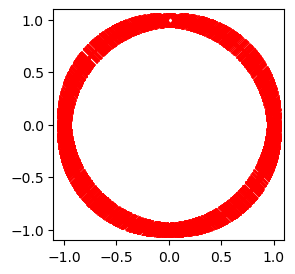

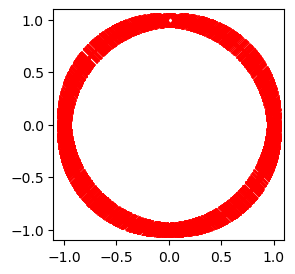

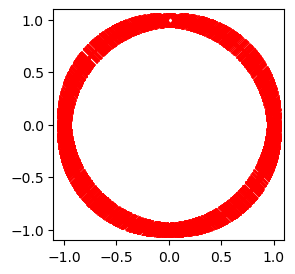

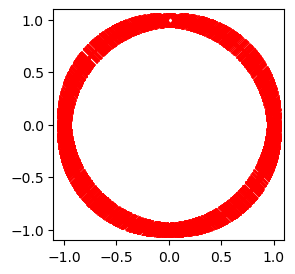

In [48]:
def getKsTerms_old(Xs1,Xs2,M=jnp.inf,F=jnp.inf):
    P=jnp.shape(Xs1)[0]
    Q=jnp.shape(Xs1)[1]
    
    Phr=(P-1)/(M-1)
    Qhr=(Q-1)/(F-1)
    
    if P<Q:
        Kv=1/Q*jnp.matmul(Xs1,Xs2.T)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/P))
        #nTrKs_min2=jnp.mean(jnp.square(1/Q*jnp.matmul(Xs1,Xs2.T)))
    else:
        Kv=1/P*jnp.matmul(Xs1.T,Xs2)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/Q))
        #nTrKs_min2=jnp.mean(jnp.square(1/P*jnp.matmul(Xs1.T,Xs2)))
            
    Term2=-(1-Phr)/P * jnp.mean(jnp.square(jnp.mean(Xs1*Xs2,axis=1)))
    Term3=-(1-Qhr)/Q * jnp.mean(jnp.square(jnp.mean(Xs1*Xs2,axis=0)))
    Term4=((1-Phr)*(1-Qhr))/(P*Q) * jnp.mean(jnp.power(Xs1*Xs2,2))
        
    v =  Term2 + Term3 + Term4
    
    nsTrKs = jnp.square(jnp.mean(Xs1*Xs2))
    
    # if M and F are infinite, or even if M and F are finite:
    numer =  (nsTrKs +v)
    denom =  (nTrKs_min2 +v)

    naive=[nsTrKs, nTrKs_min2]
    row_exp=[nsTrKs+Term2,  nTrKs_min2+Term2]
    col_exp=[nsTrKs+Term3,  nTrKs_min2+Term3]
    double_exp=[numer, denom]
        
    return naive, row_exp, col_exp, double_exp
    
for i, idxs in enumerate(neighbors_list):
    #print(i)
    #print(f"Neighbors of point {chosen_indices[i]}: {idxs}")
    #len()
    #Psub=jnp.shape(idxs)[0]
    #num_ext_rows = maxl-Psub
    #Xmodi=jnp.block([[X[idxs,:]],[jnp.zeros((num_ext_rows,Q))]])
    if i>3:
        break

    fig,ax=plt.subplots(1,1,figsize=(5,3))
    ax.plot(X[:,0],X[:,1],'o',ms=1)
    ax.plot(X[idxs,0],X[idxs,1],'rx',ms=10)
    ax.set_aspect('equal')


    Xm=X[idxs,:]
    Xm=Xm-jnp.mean(Xm,axis=0)[None,:]
    naive, row_exp, col_exp, double_exp = getKsTerms_old(Xm,Xm,M=jnp.inf,F=jnp.inf)#=getKsTerms(X,X)

    #print(naive[0]/naive[1])
    print(row_exp[0]/row_exp[1])
    #print(col_exp[0]/col_exp[1])
    #print(double_exp[0]/double_exp[1])
    

In [ ]:
# Example usage:
key = jax.random.PRNGKey(0)

#R = 3
#Rs=np.linspace(11,12,5)
Rs=np.linspace(0.5,2,10)
S = 100

nrs=[]
ests=[]
cts=[]
for R in Rs:
    key0, key = jax.random.split(key)
    chosen_indices, neighbors_list, maxl = find_neighbors_naive_jax(X, R, S, key)
    #chosen_indices, neighbors_list, maxl = find_neighbors_kNN_jax(X, 5, S, key0)
    #print("Chosen indices:", chosen_indices)
    #print(maxl)
    print(maxl,len(neighbors_list))
    if maxl==0:
        continue
    
    vals=[]
    count=0
    for i, idxs in enumerate(neighbors_list):
        #print(i)
        #print(f"Neighbors of point {chosen_indices[i]}: {idxs}")
        #len()
        if len(idxs)<=3:
            continue
        
        Psub=jnp.shape(idxs)[0]
        #num_ext_rows = maxl-Psub
        num_ext_rows = P-Psub
        
        Xm=X[idxs,:]
        #Xm=Xm-jnp.mean(Xm,axis=0)[None,:]
    
        #Xmodi=jnp.block([[Xm],[jnp.zeros((num_ext_rows,Q))]])
        
        ###naive, row_exp, col_exp, double_exp=getKsTerms(X,X,M=jnp.inf,F=jnp.inf)
        #vals.append([getKsTerms2(Xmodi,Xmodi,Psub,Q,M=jnp.inf,F=jnp.inf)])
        #vals.append([getest_all(Xmodi,Psub,Q)])
        vals.append([getest_all(Xm,Psub,Q)])
        
        count+=1
    
        #vals.append([getKsTerms(X[idxs,:],X[idxs,:],Psub,Q,M=jnp.inf,F=jnp.inf)])
    if len(vals)==0:
        continue
    if len(vals)==1:
        mvals=jnp.squeeze(jnp.array(vals))
    else:
        vals=jnp.squeeze(jnp.array(vals))
        mvals=jnp.mean(vals,axis=0)

    ests.append([mvals[0,0]/mvals[0,1], mvals[1,0]/mvals[1,1], mvals[2,0]/mvals[2,1], mvals[3,0]/mvals[3,1]])
    nrs.append(R)
    cts.append(count)


no data
1 0
no data
1 0
6 84


[100, 100, 100, 100]


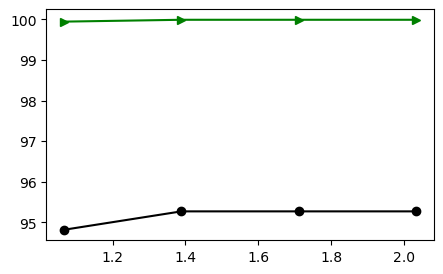

In [82]:
ests=np.array(ests)

fig,ax=plt.subplots(1,1,figsize=(5,3))
ax.plot(nrs,ests[:,0],'k-o')
ax.plot(nrs,ests[:,1],'g->')
ax.plot(nrs,ests[:,2],'g-<')
#ax.plot(nrs,ests[:,3],'r-o')
print(cts)
#ax.set_ylim([0,15])


[19, 21, 28, 42, 46, 59, 81, 101, 139, 178]


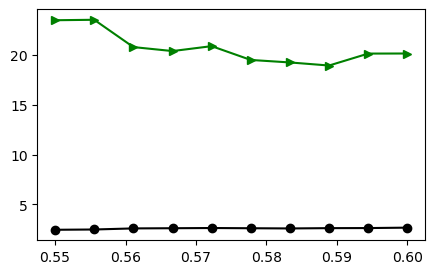

In [234]:
ests=np.array(ests)

fig,ax=plt.subplots(1,1,figsize=(5,3))
ax.plot(nrs,ests[:,0],'k-o')
ax.plot(nrs,ests[:,1],'g->')
ax.plot(nrs,ests[:,2],'g-<')
#ax.plot(nrs,ests[:,3],'r-o')
print(cts)
#ax.set_ylim([0,15])


[16, 25, 32, 49, 62]


(0.0, 15.0)

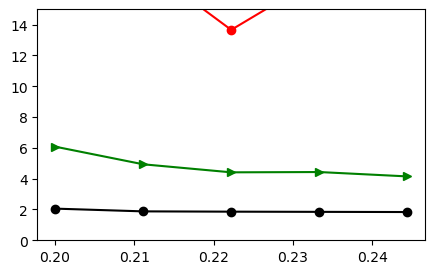

In [191]:
ests=np.array(ests)

fig,ax=plt.subplots(1,1,figsize=(5,3))
ax.plot(nrs,ests[:,0],'k-o')
ax.plot(nrs,ests[:,1],'g->')
ax.plot(nrs,ests[:,2],'g-<')
ax.plot(nrs,ests[:,3],'r-o')
print(cts)
ax.set_ylim([0,15])

In [77]:
isinstance(X, jax.numpy.ndarray)

True

In [ ]:
ests=np.array(ests)

fig,ax=plt.subplots(1,1,figsize=(5,3))
ax.plot(nrs,ests[:,0],'k-o')
ax.plot(nrs,ests[:,1],'g->')
ax.plot(nrs,ests[:,2],'g-<')
ax.plot(nrs,ests[:,3],'r-o')
print(cts)
ax.set_ylim([0,50])


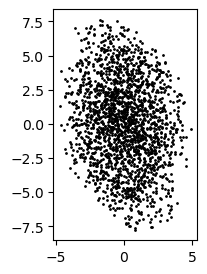

In [121]:
fig,ax=plt.subplots(1,1,figsize=(5,3))
ax.plot(X[:,1],X[:,2],'ko',ms=1)
#ax.plot(Rs,ests[:,1],'g-o')
ax.set_aspect('equal')


In [460]:
np.shape(Xmodi)

(18, 200)